# Cross-Asset Correlation Regime — a quantitative teardown 🔬
### average pairwise correlation · expanding-quantile regime split · two-sample *t* · block-shuffle placebo · coincident-drawdown mechanism · seven-spec sweep · risk-off overlay net of costs · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fragility_gauge%3F: Coincident](https://img.shields.io/badge/Fragility_gauge%3F-Coincident-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the mean off-diagonal pairwise correlation across a 14-ETF cross-asset panel, split the tape into HIGH/LOW regimes, and test whether the HIGH regime predicts lower forward returns and higher forward vol on SPY (the fragility claim) — or, here, the opposite on returns.

> ⚠️ **Not investment advice.** Real data: yfinance daily prices, 14 ETFs, 2007-01-04 → 2026-06-26 (as-of 2026-06-30, returns fp `9dbfa917d6ba`, regime/forward frame fp `0b73f61632f6`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cross_asset_correlation_regime import data, strategy as st

WINDOW, HORIZON, Q = 63, 21, 0.70

RETS = data.fetch_returns(fetch=False)          # cache-first; empty frame offline
HAVE_REAL = (not RETS.empty) and ("SPY" in RETS.columns)
# Compute the correlation index + regime once (it is the slow step) and reuse it everywhere.
if HAVE_REAL:
    AC = st.avg_pairwise_corr(RETS, window=WINDOW)
    LAB = st.regime_labels(AC, q=Q, min_periods=252)
    RES = st.regime_forward_test(RETS, window=WINDOW, horizon=HORIZON, q=Q, min_periods=252)
print("real cross-asset tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({RETS.shape[1]} ETFs, {RETS.index.min().date()} -> {RETS.index.max().date()})")


real cross-asset tape present: True (14 ETFs, 2007-01-04 -> 2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | HIGH−LOW forward-return spread **+0.98%** (two-sample *t* **+6.8**, block-placebo *p* 0.048) — the *wrong* sign, positive in **all 7** specs. Forward-vol spread +1.62% (*t* +4.62) is right-signed (turbulence). |
| **Tradability** | `MIRAGE` | Risk-off overlay net CAGR **5.55%** / Sharpe **0.42** vs buy-hold **12.2%** / **0.62**; it sat out the rebounds. |
| **Fragility gauge?** | `COINCIDENT` | Mean *contemporaneous* SPY drawdown **-11.7%** in HIGH vs **-5.3%** in LOW — correlation spikes *inside* the crash. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this cross-asset tape the fragility claim is the wrong sign on returns and only coincident on stress. It is a real *nowcast* of stress, not a *forecast* of losses.

## 1 · The claim, steelmanned

Let $\bar\rho_t$ be the trailing average pairwise correlation across the panel, $H_t$ the HIGH-regime indicator ($\bar\rho_t$ above its expanding $q$-quantile), and $r_{t\to t+h}$ SPY's forward $h$-day return.

- **H₁ (fragility / returns).** $\mathbb{E}[r \mid H=1] - \mathbb{E}[r \mid H=0] < 0$ at *t* ≤ −2 (high correlation → lower forward return).
- **H₂ (turbulence / vol).** forward vol is higher in the HIGH regime (positive spread).
- **H₃ (robustness).** the *sign* of H₁ is stable across window/horizon/quantile.
- **H₄ (tradable).** a risk-off overlay on the HIGH regime beats buy-and-hold net.

We find **H₁ rejected with the sign reversed** (forward return is *higher* in HIGH), **H₂ supported** (vol is higher), **H₃ rejected for the claim** (the spread is stably the *wrong* sign), and **H₄ rejected** (the overlay underperforms).

## 2 · So what? — what rides on each answer

The content is the **why**. Correlation clustering is real and well documented (Longin & Solnik 2001; Ang & Chen 2002) — but it is a property of *bear* markets, i.e. it is **coincident** with drawdowns, not a *lead*. Pollet & Wilson (2010) find average *equity* correlation forecasts market variance; the return-timing folklore is the folk extension this study puts on the tape. The mechanism that flips the sign: correlation peaks near the *bottom* of a sell-off, and the forward window catches the rebound — the same reason the [502 Betting-Against-Correlation](../../502-betting-against-correlation/) premium concentrates in correlation-spike years.

## 3 · How we'd know — the protocol

- **Index.** $\bar\rho_t$ = mean off-diagonal of the trailing-63-day pairwise correlation matrix of the 14-ETF panel (trailing only).
- **Regime.** HIGH if $\bar\rho_t$ > its *expanding* 70th percentile (past data only, 252-day warm-up). No look-ahead in the threshold.
- **Forward.** SPY's forward 21-day return and annualised realised vol, measured strictly *after* day *t*.
- **Inference.** Two-sample (Welch) *t* on HIGH vs LOW; a **block-shuffle placebo** null (21-day blocks, 2000 perms) because the forward windows overlap.
- **Mechanism.** Contemporaneous SPY drawdown in each regime; the HIGH-regime calendar.
- **Robustness.** Seven (window, horizon, q) specs; read the sign.
- **Tradable.** Risk-off overlay (flat in HIGH, 1-day lag), gross and net of 5 bps/switch.
- **Positive control.** A deterministic synthetic world with a planted fragility effect (and a null), averaged over 25 seeds (house rule).

Timing: the regime label is public at day *t*'s close (trailing window + expanding quantile); the forward series is strictly after *t*; the overlay enters one bar later (the single documented execution lag). No future data enters the signal.

## 4 · The teardown

### 4a · The regime forward test — H₁ & H₂

HIGH vs LOW forward return and vol, with the two-sample *t* and the block-shuffle placebo.

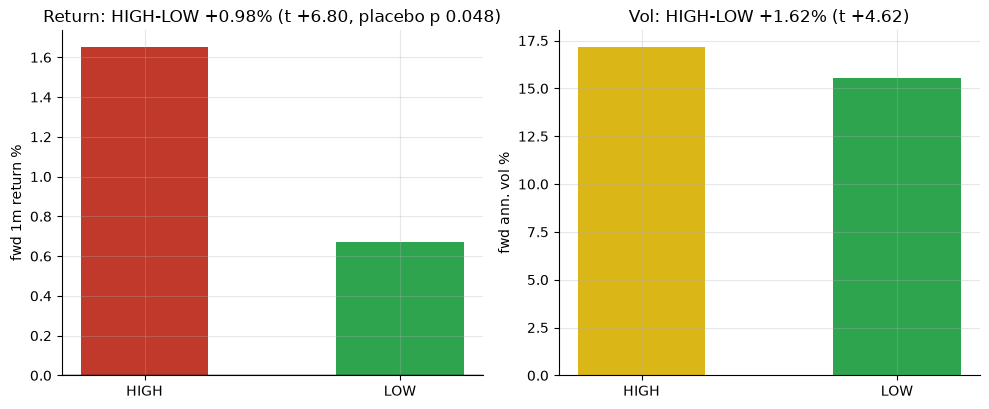

RET  HIGH +1.65% | LOW +0.67% | spread +0.98% | t +6.80 | placebo p 0.048
VOL  HIGH 17.2% | LOW 15.6% | spread +1.62% | t +4.62


In [2]:
if HAVE_REAL:
    p = st.placebo_pvalue(RES, n_perm=2000, block=21, seed=578)
    hi_r, lo_r, r_spr, r_t = RES['high_fwd_ret']*100, RES['low_fwd_ret']*100, RES['ret_spread']*100, RES['ret_t']
    hi_v, lo_v, v_spr, v_t = RES['high_fwd_vol']*100, RES['low_fwd_vol']*100, RES['vol_spread']*100, RES['vol_t']
else:
    hi_r, lo_r, r_spr, r_t, p = 1.65, 0.67, 0.98, 6.8, 0.048
    hi_v, lo_v, v_spr, v_t = 17.2, 15.6, 1.62, 4.62
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
ax[0].bar(['HIGH','LOW'], [hi_r, lo_r], color=[RED, GREEN], width=.5); ax[0].axhline(0, c='k', lw=1)
ax[0].set_ylabel('fwd 1m return %'); ax[0].set_title(f'Return: HIGH-LOW {r_spr:+.2f}% (t {r_t:+.2f}, placebo p {p:.3f})')
ax[1].bar(['HIGH','LOW'], [hi_v, lo_v], color=[AMBER, GREEN], width=.5)
ax[1].set_ylabel('fwd ann. vol %'); ax[1].set_title(f'Vol: HIGH-LOW {v_spr:+.2f}% (t {v_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'RET  HIGH +{hi_r:.2f}% | LOW +{lo_r:.2f}% | spread {r_spr:+.2f}% | t {r_t:+.2f} | placebo p {p:.3f}')
print(f'VOL  HIGH {hi_v:.1f}% | LOW {lo_v:.1f}% | spread {v_spr:+.2f}% | t {v_t:+.2f}')

> 💡 In plain words: **H₁ rejected, sign reversed** — the forward-return spread is **+0.98%** (*t* +6.8, placebo *p* 0.048): high correlation was followed by *higher* returns. **H₂ supported** — forward vol *is* higher in HIGH (+1.62%, *t* +4.62). Correlation flags turbulence, not losses.

### 4b · Why the sign flips — the coincident-drawdown mechanism

Where is SPY, *right now*, when correlation is HIGH? Measure the contemporaneous drawdown in each regime.

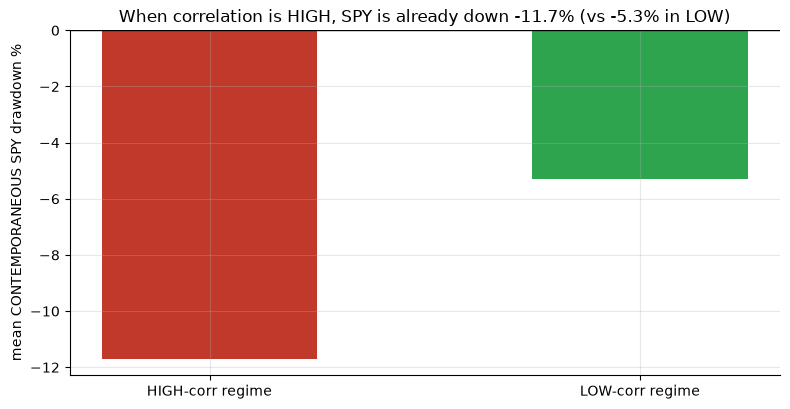

contemporaneous SPY drawdown -> HIGH -11.7% | LOW -5.3%


In [3]:
if HAVE_REAL:
    spy = RETS['SPY']; eq = (1+spy).cumprod(); dd = eq/eq.cummax()-1
    d = pd.DataFrame({'lab': LAB, 'dd': dd}).dropna()
    dd_hi, dd_lo = d[d.lab==1].dd.mean()*100, d[d.lab==0].dd.mean()*100
    ac_series = AC.dropna()
else:
    dd_hi, dd_lo = -11.7, -5.3
    ac_series = None
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(['HIGH-corr regime','LOW-corr regime'], [dd_hi, dd_lo], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean CONTEMPORANEOUS SPY drawdown %')
ax.set_title(f'When correlation is HIGH, SPY is already down {dd_hi:.1f}% (vs {dd_lo:.1f}% in LOW)')
plt.tight_layout(); plt.show()
print(f'contemporaneous SPY drawdown -> HIGH {dd_hi:.1f}% | LOW {dd_lo:.1f}%')

> 💡 In plain words: the HIGH-correlation regime *is* the drawdown — SPY sits **-11.7%** below its peak on average there, vs **-5.3%** in LOW. Correlation peaks near the *bottom*; the forward month is the rebound. That is the whole sign flip.

### 4c · Robustness — H₃ (does the sign hold?)

The forward-return spread across seven (window, horizon, quantile) specs. A real fragility signal would be *negative* everywhere; here it is stably *positive*.

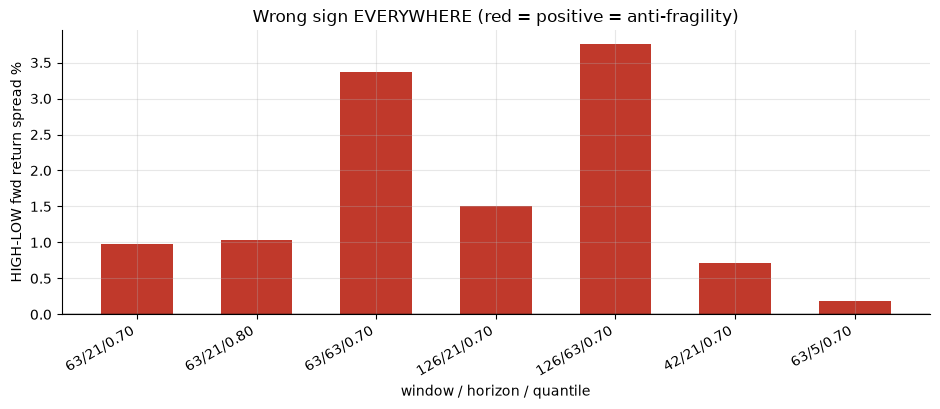

ret spreads by spec: [0.98, 1.03, 3.37, 1.5, 3.76, 0.72, 0.18]


In [4]:
sweep = [(63, 21, 0.7, 0.98, 6.8, 1.62, 4.62), (63, 21, 0.8, 1.03, 6.62, 1.03, 3.01), (63, 63, 0.7, 3.37, 14.81, -0.06, -0.18), (126, 21, 0.7, 1.5, 10.64, 0.51, 1.47), (126, 63, 0.7, 3.76, 16.75, -1.03, -3.34), (42, 21, 0.7, 0.72, 4.94, 1.57, 4.52), (63, 5, 0.7, 0.18, 2.36, 2.77, 6.63)]
if HAVE_REAL:
    specs = [(w,h,q) for (w,h,q,*_) in sweep]
    sw = st.robustness_sweep(RETS, specs)
    labs = [f'{int(w)}/{int(h)}/{q:.2f}' for w,h,q in zip(sw['window'],sw['horizon'],sw['q'])]
    rspr = list(sw['ret_spread']*100)
else:
    labs = [f'{w}/{h}/{q:.2f}' for (w,h,q,*_) in sweep]
    rspr = [s for (_,_,_,s,_,_,_) in sweep]
fig, ax = plt.subplots(figsize=(9.5, 4.2))
cols = [RED if s>0 else GREEN for s in rspr]
ax.bar(range(len(labs)), rspr, color=cols, width=.6)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=30, ha='right')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HIGH-LOW fwd return spread %')
ax.set_xlabel('window / horizon / quantile')
ax.set_title('Wrong sign EVERYWHERE (red = positive = anti-fragility)')
plt.tight_layout(); plt.show()
print('ret spreads by spec:', [round(s,2) for s in rspr])

> 💡 In plain words: H₃ **rejected for the claim** — the forward-return spread is **positive in all seven specs** (+0.18% to +3.76%). The fragility sign (negative) never shows up. What is stable here is the *anti*-fragility.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (spread +0.98%, *t* +6.8, wrong sign; placebo *p* 0.048); stable positive across all specs.
- **Tradability `MIRAGE`** — risk-off overlay net 5.55%/yr, Sharpe 0.42 vs buy-hold 12.2%/yr, Sharpe 0.62.
- **Fragility gauge? `COINCIDENT`** — a real stress *nowcast* (higher forward vol, deep contemporaneous drawdown), not a leading return predictor.

## 6 · Could you trade it? — the risk-off overlay net of costs

Flat in the HIGH regime, long SPY in LOW, one-day lag, 5 bps per switch. Does dodging the 'fragile' regime pay?

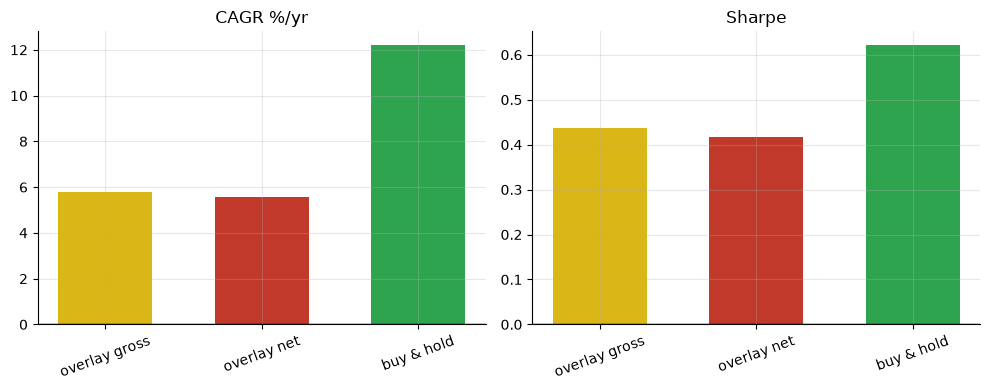

               CAGR%   vol%  Sharpe  maxDD%
overlay gross   5.81  13.31    0.44  -37.46
overlay net     5.55  13.31    0.42  -37.46
buy & hold     12.20  19.64    0.62  -55.19
switches: 98


In [5]:
if HAVE_REAL:
    ov = st.overlay_backtest(RETS, window=WINDOW, q=Q, cost_bps=5.0)
    og, on, bh = ov['overlay_gross'], ov['overlay_net'], ov['buy_hold']
    rows = [('overlay gross', og), ('overlay net', on), ('buy & hold', bh)]
    tab = pd.DataFrame({k: {'CAGR%': v['cagr']*100, 'vol%': v['vol']*100,
                            'Sharpe': v['sharpe'], 'maxDD%': v['maxdd']*100} for k,v in rows}).T
    sw_n = ov['switches']
else:
    tab = pd.DataFrame({'overlay gross': {'CAGR%': 5.81, 'vol%': 13.3, 'Sharpe': 0.44, 'maxDD%': -37.5},
                        'overlay net': {'CAGR%': 5.55, 'vol%': 13.3, 'Sharpe': 0.42, 'maxDD%': -37.5},
                        'buy & hold': {'CAGR%': 12.2, 'vol%': 19.6, 'Sharpe': 0.62, 'maxDD%': -55.2}}).T
    sw_n = 98
fig, ax = plt.subplots(1, 2, figsize=(10, 4.0))
ax[0].bar(tab.index, tab['CAGR%'], color=[AMBER, RED, GREEN], width=.6); ax[0].set_title('CAGR %/yr'); ax[0].axhline(0,c='k',lw=1)
ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(tab.index, tab['Sharpe'], color=[AMBER, RED, GREEN], width=.6); ax[1].set_title('Sharpe'); ax[1].axhline(0,c='k',lw=1)
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print(tab.round(2).to_string()); print('switches:', sw_n)

> 💡 In plain words: the overlay cut the drawdown (-37.5% vs -55.2%) but at a brutal cost to return (5.55%/yr vs 12.2%/yr) and a *lower* Sharpe (0.42 vs 0.62) — it sat out the rebounds. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print a positive spread? Plant a *real* fragility effect (`fragility > 0`: high correlation genuinely precedes worse returns) of increasing strength and watch the HIGH−LOW spread go *negative* — averaged over 25 seeds so no single lucky seed can fake it.

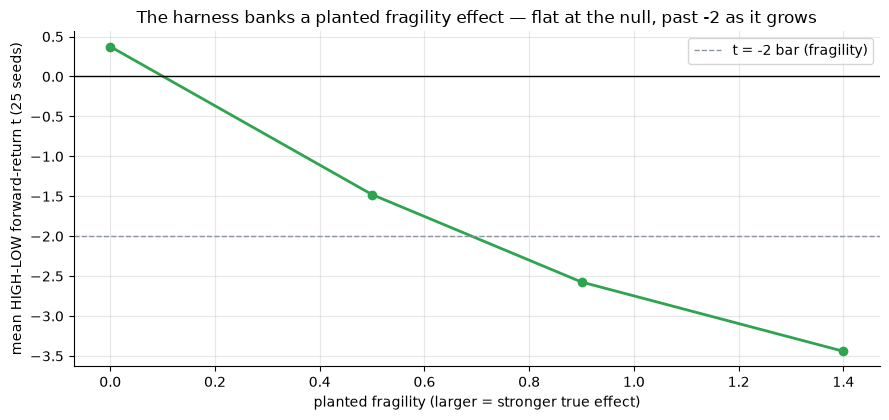

fragility +0.00 -> mean spread +0.05% | mean t +0.37
fragility +0.50 -> mean spread -0.26% | mean t -1.48
fragility +0.90 -> mean spread -0.50% | mean t -2.57
fragility +1.40 -> mean spread -0.78% | mean t -3.44


In [6]:
ctrl = [(0.0, 0.05, 0.37), (0.5, -0.26, -1.48), (0.9, -0.5, -2.57), (1.4, -0.78, -3.44)]
fragilities = [0.0, 0.5, 0.9, 1.4]
res = [st.synthetic_mean_t(data, fragility=f, n_seeds=25) for f in fragilities]
spreads = [s*100 for s,_ in res]; ts = [t for _,t in res]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(fragilities, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (fragility)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted fragility (larger = stronger true effect)')
ax.set_ylabel('mean HIGH-LOW forward-return t (25 seeds)')
ax.set_title('The harness banks a planted fragility effect — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for f,(s,t) in zip(fragilities, res): print(f'fragility {f:+.2f} -> mean spread {s*100:+.2f}% | mean t {t:+.2f}')

The mean *t* is ≈ 0 at the null and falls past −2 as the planted fragility grows — so the engine is a faithful detector *with the right sign convention*. The real-tape result is therefore a statement about **this cross-asset tape over 2007-2026**: rising average correlation is a coincident stress gauge that, as a forward return signal, is the *wrong sign*. For the single-pair and cross-sectional cousins see [245 Oil-Equity-Correlation](../../245-oil-equity-correlation/) and [502 Betting-Against-Correlation](../../502-betting-against-correlation/).